# DATA 620 Project 1: Centrality in the U.S. House of Representatives

**Student:** Sachi Kapoor  
**Course:** DATA 620: Web Analytics  
**Semester:** Fall 2026

## Project Overview

For this project, I will analyze bill sponsorship and co-sponsorship relationships among members of the U.S. House of Representatives during the 118th Congress.

Each node will represent a member of the House. A connection will be created when two representatives are connected through the sponsorship and co-sponsorship of a bill. The categorical variable used for comparison will be political party.

The goal is to calculate degree centrality and eigenvector centrality for each representative and determine whether these measures differ across political parties.

## Research Questions

1. Are there differences in degree centrality across political parties?
2. Are there differences in eigenvector centrality across political parties?
3. Which representatives hold the most central positions in the co-sponsorship network?

In [1]:
import requests
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict
from getpass import getpass
from scipy import stats
from IPython.display import display

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid")

print("Packages loaded successfully.")

Packages loaded successfully.


In [4]:
import getpass as gp

API_KEY = gp.getpass("Enter your Congress.gov API key: ")
BASE_URL = "https://api.congress.gov/v3"

print("API key entered securely.")

Enter your Congress.gov API key:  ········


API key entered securely.


In [5]:
test_url = f"{BASE_URL}/bill/118/hr"

test_response = requests.get(
    test_url,
    params={
        "api_key": API_KEY,
        "format": "json",
        "limit": 1
    },
    timeout=30
)

print("Status code:", test_response.status_code)

if test_response.status_code == 200:
    print("Congress.gov API connection successful.")
else:
    print("Connection failed:", test_response.text[:300])

Status code: 200
Congress.gov API connection successful.


## Data Collection

The data was collected from the official Congress.gov API. The analysis focused on bills from the U.S. House of Representatives during the 118th Congress.

Because the 118th Congress contained thousands of House bills, this project used a sample of 250 bills returned by the API. For each bill, the sponsor and co-sponsors were collected. A connection was created between each bill's sponsor and its co-sponsors.

The resulting network was undirected and weighted. The edge weight represented the number of sampled bills on which two representatives were connected through sponsorship and co-sponsorship.

Political party was used as the categorical variable for comparing centrality measures.

### Data Source

The data was retrieved from the official [Congress.gov API](https://api.congress.gov/) on October 3, 2026. The `/bill/118/hr` endpoint was used to obtain House bills from the 118th Congress. The bill-detail and cosponsor endpoints were then used to collect sponsor and cosponsor information.

The analysis uses the first 250 records returned by the API and is therefore a convenience sample rather than a random sample.

In [6]:
# Request a sample of House bills from the 118th Congress
BILL_LIMIT = 250

bills_response = requests.get(
    f"{BASE_URL}/bill/118/hr",
    params={
        "api_key": API_KEY,
        "format": "json",
        "limit": BILL_LIMIT
    },
    timeout=30
)

bills_response.raise_for_status()
bills_data = bills_response.json()

bills = bills_data["bills"]

print("Number of bills collected:", len(bills))

Number of bills collected: 250


In [7]:
bills_df = pd.DataFrame(bills)

bills_df.head()

,congress,introducedDate,latestAction,number,originChamber,originChamberCode,title,type,updateDate,updateDateIncludingText,url
0,118,2023-01-09,"{'actionDate': '2023-01-09', 'text': 'Referred...",27,House,H,Prosecutors Need to Prosecute Act,HR,2025-05-27,2025-05-27,https://api.congress.gov/v3/bill/118/hr/27?for...
1,118,2023-01-09,"{'actionDate': '2023-01-09', 'text': 'Referred...",49,House,H,REVIEW Act of 2023,HR,2025-12-05,2025-12-05,https://api.congress.gov/v3/bill/118/hr/49?for...
2,118,2023-01-09,"{'actionDate': '2023-01-09', 'text': 'Referred...",53,House,H,FIND Act,HR,2025-12-05,2025-12-05,https://api.congress.gov/v3/bill/118/hr/53?for...
3,118,2023-01-09,"{'actionDate': '2023-01-09', 'text': 'Referred...",208,House,H,Pet Safety and Protection Act of 2023,HR,2025-05-27,2025-05-27,https://api.congress.gov/v3/bill/118/hr/208?fo...
4,118,2023-01-09,"{'actionDate': '2023-01-09', 'text': 'Referred...",31,House,H,COVER Now Act,HR,2024-07-24,2024-07-24,https://api.congress.gov/v3/bill/118/hr/31?for...


### Inspecting the API Structure

Before collecting information for all 250 bills, I first examine one bill to confirm how the sponsor and co-sponsor information is organized in the API response.

In [8]:
# Select the first bill in the sample
sample_bill = bills[0]
sample_number = sample_bill["number"]

print("Sample bill number:", sample_number)

# Request detailed information about the bill
detail_response = requests.get(
    f"{BASE_URL}/bill/118/hr/{sample_number}",
    params={
        "api_key": API_KEY,
        "format": "json"
    },
    timeout=30
)

detail_response.raise_for_status()
sample_detail = detail_response.json()["bill"]

print("\nAvailable bill-detail fields:")
print(sample_detail.keys())

print("\nSponsor information:")
print(sample_detail.get("sponsors"))

Sample bill number: 27

Available bill-detail fields:
dict_keys(['actions', 'cboCostEstimates', 'committees', 'congress', 'constitutionalAuthorityStatementText', 'cosponsors', 'introducedDate', 'latestAction', 'legislationUrl', 'number', 'originChamber', 'originChamberCode', 'policyArea', 'relatedBills', 'sponsors', 'subjects', 'summaries', 'textVersions', 'title', 'titles', 'type', 'updateDate', 'updateDateIncludingText'])

Sponsor information:
[{'bioguideId': 'M000317', 'district': 11, 'firstName': 'Nicole', 'fullName': 'Rep. Malliotakis, Nicole [R-NY-11]', 'isByRequest': 'N', 'lastName': 'Malliotakis', 'party': 'R', 'state': 'NY', 'url': 'https://api.congress.gov/v3/member/M000317?format=json'}]


In [9]:
# Request the co-sponsors for the same bill
cosponsor_response = requests.get(
    f"{BASE_URL}/bill/118/hr/{sample_number}/cosponsors",
    params={
        "api_key": API_KEY,
        "format": "json",
        "limit": 250
    },
    timeout=30
)

cosponsor_response.raise_for_status()
sample_cosponsors = cosponsor_response.json().get("cosponsors", [])

print("Number of co-sponsors:", len(sample_cosponsors))

if sample_cosponsors:
    display(pd.DataFrame(sample_cosponsors).head())
else:
    print("This bill does not have any co-sponsors.")

Number of co-sponsors: 32


,bioguideId,district,firstName,fullName,isOriginalCosponsor,lastName,party,sponsorshipDate,state,url,middleName,sponsorshipWithdrawnDate
0,R000610,14,Guy,"Rep. Reschenthaler, Guy [R-PA-14]",True,Reschenthaler,R,2023-01-09,PA,https://api.congress.gov/v3/member/R000610?for...,NaN,NaN
1,S001196,21,Elise,"Rep. Stefanik, Elise M. [R-NY-21]",True,Stefanik,R,2023-01-09,NY,https://api.congress.gov/v3/member/S001196?for...,M.,NaN
2,V000134,24,Beth,"Rep. Van Duyne, Beth [R-TX-24]",True,Van Duyne,R,2023-01-09,TX,https://api.congress.gov/v3/member/V000134?for...,NaN,NaN
3,N000189,4,Dan,"Rep. Newhouse, Dan [R-WA-4]",True,Newhouse,R,2023-01-09,WA,https://api.congress.gov/v3/member/N000189?for...,NaN,NaN
4,J000299,4,Mike,"Rep. Johnson, Mike [R-LA-4]",True,Johnson,R,2023-01-09,LA,https://api.congress.gov/v3/member/J000299?for...,NaN,NaN


In [11]:
# Containers for the collected data
member_info = {}
edge_weights = defaultdict(int)
bill_records = []
collection_errors = []

# Collect sponsor and co-sponsor data for all 250 bills
for index, bill in enumerate(bills, start=1):

    bill_number = bill["number"]

    try:
        # Get the sponsor
        detail_response = requests.get(
            f"{BASE_URL}/bill/118/hr/{bill_number}",
            params={
                "api_key": API_KEY,
                "format": "json"
            },
            timeout=30
        )

        detail_response.raise_for_status()
        detail = detail_response.json()["bill"]
        sponsors = detail.get("sponsors", [])

        if not sponsors:
            continue

        sponsor = sponsors[0]
        sponsor_id = sponsor.get("bioguideId")

        if not sponsor_id:
            continue

        member_info[sponsor_id] = {
            "name": sponsor.get("fullName"),
            "party": sponsor.get("party"),
            "state": sponsor.get("state"),
            "district": sponsor.get("district")
        }

        # Get the co-sponsors
        cosponsor_response = requests.get(
            f"{BASE_URL}/bill/118/hr/{bill_number}/cosponsors",
            params={
                "api_key": API_KEY,
                "format": "json",
                "limit": 250
            },
            timeout=30
        )

        cosponsor_response.raise_for_status()
        cosponsors = cosponsor_response.json().get("cosponsors", [])

        for cosponsor in cosponsors:

            cosponsor_id = cosponsor.get("bioguideId")

            if not cosponsor_id or cosponsor_id == sponsor_id:
                continue

            member_info[cosponsor_id] = {
                "name": cosponsor.get("fullName"),
                "party": cosponsor.get("party"),
                "state": cosponsor.get("state"),
                "district": cosponsor.get("district")
            }

            # Create a consistent undirected connection
            edge = tuple(sorted([sponsor_id, cosponsor_id]))
            edge_weights[edge] += 1

        bill_records.append({
            "bill_number": bill_number,
            "sponsor_id": sponsor_id,
            "number_of_cosponsors": len(cosponsors)
        })

    except Exception as error:
        collection_errors.append({
            "bill_number": bill_number,
            "error": str(error)
        })

    if index % 25 == 0:
        print(f"Processed {index} of {len(bills)} bills")

    time.sleep(0.05)

print()
print("Collection complete.")
print("Bills successfully processed:", len(bill_records))
print("Representatives collected:", len(member_info))
print("Unique sponsor/co-sponsor connections:", len(edge_weights))
print("Bills with collection errors:", len(collection_errors))

Processed 25 of 250 bills
Processed 50 of 250 bills
Processed 75 of 250 bills
Processed 100 of 250 bills
Processed 125 of 250 bills
Processed 150 of 250 bills
Processed 175 of 250 bills
Processed 200 of 250 bills
Processed 225 of 250 bills
Processed 250 of 250 bills

Collection complete.
Bills successfully processed: 250
Representatives collected: 448
Unique sponsor/co-sponsor connections: 3038
Bills with collection errors: 0


## Building the Congressional Collaboration Network

An undirected NetworkX graph was created from the collected sponsorship data. Each node represents a member of Congress, and each edge represents at least one instance in which one representative sponsored a bill and another representative co-sponsored it. Edge weights indicate the number of bills connecting the two representatives.

In [12]:
# Create the undirected network
G = nx.Graph()

# Add representatives as nodes with categorical attributes
for member_id, attributes in member_info.items():
    G.add_node(member_id, **attributes)

# Add sponsor/co-sponsor connections
for (source, target), weight in edge_weights.items():
    G.add_edge(source, target, weight=weight)

# Display basic network statistics
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))
print("Network density:", round(nx.density(G), 4))

Number of nodes: 448
Number of edges: 3038
Connected components: 1
Network density: 0.0303


## Centrality Measures

Degree centrality measures the proportion of representatives to whom each member is directly connected. A higher degree centrality indicates that a representative collaborated with more members.

Eigenvector centrality considers both the number and importance of a representative's connections. The edge weights are included so that repeated collaborations have a greater influence on the calculation.

In [14]:
# Calculate degree centrality
degree_centrality = nx.degree_centrality(G)

# Calculate weighted eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(
    G,
    max_iter=2000,
    weight="weight"
)

# Create a dataframe containing each representative's results
centrality_df = pd.DataFrame([
    {
        "member_id": node,
        "name": G.nodes[node].get("name"),
        "party": G.nodes[node].get("party"),
        "state": G.nodes[node].get("state"),
        "degree_centrality": degree_centrality[node],
        "eigenvector_centrality": eigenvector_centrality[node]
    }
    for node in G.nodes()
])

print("Representatives analyzed:", len(centrality_df))
display(centrality_df.head())

print("\nRepresentatives by party:")
display(centrality_df["party"].value_counts())

Representatives analyzed: 448


,member_id,name,party,state,degree_centrality,eigenvector_centrality
0,M000317,"Rep. Malliotakis, Nicole [R-NY-11]",R,NY,0.0940,0.0540
1,R000610,"Rep. Reschenthaler, Guy [R-PA-14]",R,PA,0.0336,0.0563
2,S001196,"Rep. Stefanik, Elise M. [R-NY-21]",R,NY,0.0336,0.0275
3,V000134,"Rep. Van Duyne, Beth [R-TX-24]",R,TX,0.0336,0.0298
4,N000189,"Rep. Newhouse, Dan [R-WA-4]",R,WA,0.0291,0.0236



Representatives by party:


party
R    228
D    220
Name: count, dtype: int64

## Comparison of Centrality by Political Party

The representatives were grouped by political party to compare their degree and eigenvector centrality scores. Mean and median values were calculated for each party. Welch's independent-samples t-test was also used because it does not assume that the two groups have equal variances.

The null hypothesis is that Democrats and Republicans have the same mean centrality. A p-value below 0.05 will be treated as evidence of a statistically significant difference.

In [26]:
# Add full party names for clearer tables and visualizations
centrality_df["party_name"] = centrality_df["party"].map({
    "D": "Democrat",
    "R": "Republican"
})

# Create summary statistics by party
party_summary = centrality_df.groupby("party_name").agg(
    representatives=("member_id", "count"),
    mean_degree=("degree_centrality", "mean"),
    median_degree=("degree_centrality", "median"),
    std_degree=("degree_centrality", "std"),
    mean_eigenvector=("eigenvector_centrality", "mean"),
    median_eigenvector=("eigenvector_centrality", "median"),
    std_eigenvector=("eigenvector_centrality", "std")
).round(4)

display(party_summary)

# Separate the two party groups
democrats = centrality_df[centrality_df["party"] == "D"]
republicans = centrality_df[centrality_df["party"] == "R"]

# Welch's t-tests
degree_test = stats.ttest_ind(
    democrats["degree_centrality"],
    republicans["degree_centrality"],
    equal_var=False
)

eigenvector_test = stats.ttest_ind(
    democrats["eigenvector_centrality"],
    republicans["eigenvector_centrality"],
    equal_var=False
)

print("Degree centrality Welch's t-test")
print(f"t-statistic: {degree_test.statistic:.4f}")
print(f"p-value: {degree_test.pvalue:.2e}")

print("\nEigenvector centrality Welch's t-test")
print(f"t-statistic: {eigenvector_test.statistic:.4f}")
print(f"p-value: {eigenvector_test.pvalue:.2e}")

,representatives,mean_degree,median_degree,std_degree,mean_eigenvector,median_eigenvector,std_eigenvector
party_name,,,,,,,
Democrat,220,0.0169,0.0089,0.0467,0.0078,0.0066,0.0074
Republican,228,0.0433,0.0224,0.0724,0.0449,0.0333,0.0476


Degree centrality Welch's t-test
t-statistic: -4.6189
p-value: 5.25e-06

Eigenvector centrality Welch's t-test
t-statistic: -11.6245
p-value: 4.86e-25


## Interpretation of the Party Comparison

Republicans had a higher mean degree centrality than Democrats, with average scores of 0.0433 and 0.0169, respectively. This suggests that Republican representatives in this network were directly connected to more representatives on average.

Republicans also had a higher mean eigenvector centrality, with an average of 0.0449 compared with 0.0078 for Democrats. This indicates that Republicans were more likely to be connected to other highly connected representatives.

Welch's t-tests found statistically significant differences between the parties for degree centrality, t = -4.6189, p < 0.0001, and eigenvector centrality, t = -11.6245, p < 0.0001. Therefore, the null hypothesis of equal party means was rejected for both measures.

These findings apply to the 250 House bills included in this sample and should not automatically be generalized to every bill introduced during the 118th Congress.

## Centrality Distributions by Party

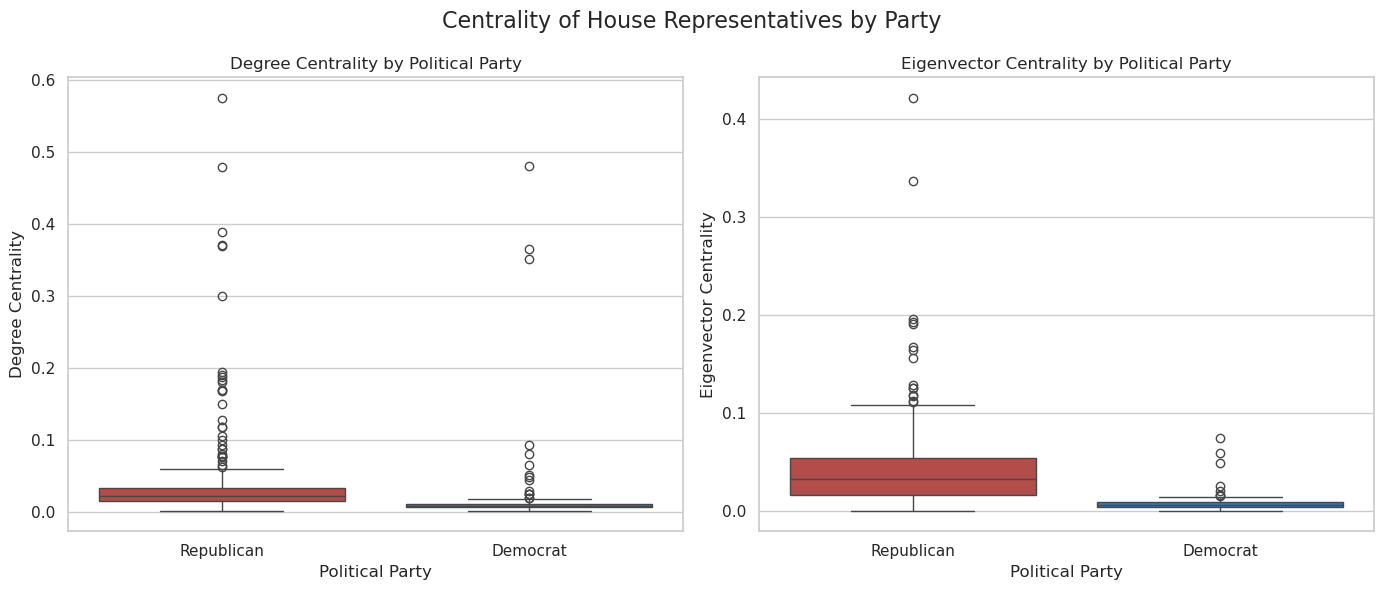

In [17]:
# Set party colors
party_colors = {
    "Democrat": "#2E74C0",
    "Republican": "#C43C39"
}

# Create side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=centrality_df,
    x="party_name",
    y="degree_centrality",
    hue="party_name",
    palette=party_colors,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Degree Centrality by Political Party")
axes[0].set_xlabel("Political Party")
axes[0].set_ylabel("Degree Centrality")

sns.boxplot(
    data=centrality_df,
    x="party_name",
    y="eigenvector_centrality",
    hue="party_name",
    palette=party_colors,
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Eigenvector Centrality by Political Party")
axes[1].set_xlabel("Political Party")
axes[1].set_ylabel("Eigenvector Centrality")

plt.suptitle("Centrality of House Representatives by Party", fontsize=16)
plt.tight_layout()
plt.show()

## Most Central Representatives

The representatives with the highest degree centrality and eigenvector centrality were identified. High degree centrality represents collaboration with many different members, while high eigenvector centrality represents connections to other influential and highly connected members.

In [18]:
# Ten representatives with the highest degree centrality
top_degree = centrality_df.nlargest(
    10, "degree_centrality"
)[
    ["name", "party_name", "state", "degree_centrality"]
].reset_index(drop=True)

top_degree.index = top_degree.index + 1

# Ten representatives with the highest eigenvector centrality
top_eigenvector = centrality_df.nlargest(
    10, "eigenvector_centrality"
)[
    ["name", "party_name", "state", "eigenvector_centrality"]
].reset_index(drop=True)

top_eigenvector.index = top_eigenvector.index + 1

print("Top 10 Representatives by Degree Centrality")
display(top_degree.round(4))

print("\nTop 10 Representatives by Eigenvector Centrality")
display(top_eigenvector.round(4))

Top 10 Representatives by Degree Centrality


,name,party_name,state,degree_centrality
1,"Rep. Graves, Garret [R-LA-6]",Republican,LA,0.5749
2,"Del. Norton, Eleanor Holmes [D-DC-At Large]",Democrat,DC,0.4810
3,"Rep. Smith, Christopher H. [R-NJ-4]",Republican,NJ,0.4787
4,"Rep. Hudson, Richard [R-NC-9]",Republican,NC,0.3893
5,"Rep. Wagner, Ann [R-MO-2]",Republican,MO,0.3714
6,"Rep. Bergman, Jack [R-MI-1]",Republican,MI,0.3691
7,"Rep. Jackson Lee, Sheila [D-TX-18]",Democrat,TX,0.3647
8,"Rep. Doggett, Lloyd [D-TX-37]",Democrat,TX,0.3512
9,"Rep. Duncan, Jeff [R-SC-3]",Republican,SC,0.2998
10,"Rep. Biggs, Andy [R-AZ-5]",Republican,AZ,0.1946



Top 10 Representatives by Eigenvector Centrality


,name,party_name,state,eigenvector_centrality
1,"Rep. Duncan, Jeff [R-SC-3]",Republican,SC,0.4211
2,"Rep. Biggs, Andy [R-AZ-5]",Republican,AZ,0.3360
3,"Rep. Smith, Christopher H. [R-NJ-4]",Republican,NJ,0.1965
4,"Rep. Hudson, Richard [R-NC-9]",Republican,NC,0.1929
5,"Rep. Bergman, Jack [R-MI-1]",Republican,MI,0.1909
6,"Rep. Wagner, Ann [R-MO-2]",Republican,MO,0.1673
7,"Rep. Massie, Thomas [R-KY-4]",Republican,KY,0.1649
8,"Rep. Gosar, Paul A. [R-AZ-9]",Republican,AZ,0.1566
9,"Rep. Kelly, Mike [R-PA-16]",Republican,PA,0.1291
10,"Rep. Roy, Chip [R-TX-21]",Republican,TX,0.1260


### Interpretation of the Most Central Representatives

Representative Garret Graves had the highest degree centrality, with a score of 0.5749. This means that he had direct sponsorship or co-sponsorship connections with approximately 57.5% of the other representatives in the sampled network.

Representative Jeff Duncan had the highest eigenvector centrality, with a score of 0.4211. Although he did not have the highest number of direct connections, his connections included other representatives who were themselves highly connected.

The two measures therefore identify different forms of importance. Degree centrality focuses on the number of direct connections, while eigenvector centrality also considers the influence of those connections.

All ten representatives with the highest eigenvector centrality were Republicans, which is consistent with the party-level finding that Republicans had significantly higher eigenvector centrality in this sample.

## Network Visualization

The network below displays representatives as nodes and bill sponsorship relationships as edges. Blue nodes represent Democrats, and red nodes represent Republicans. Node size is based on eigenvector centrality, so larger nodes represent members who are more strongly connected to other influential representatives. 

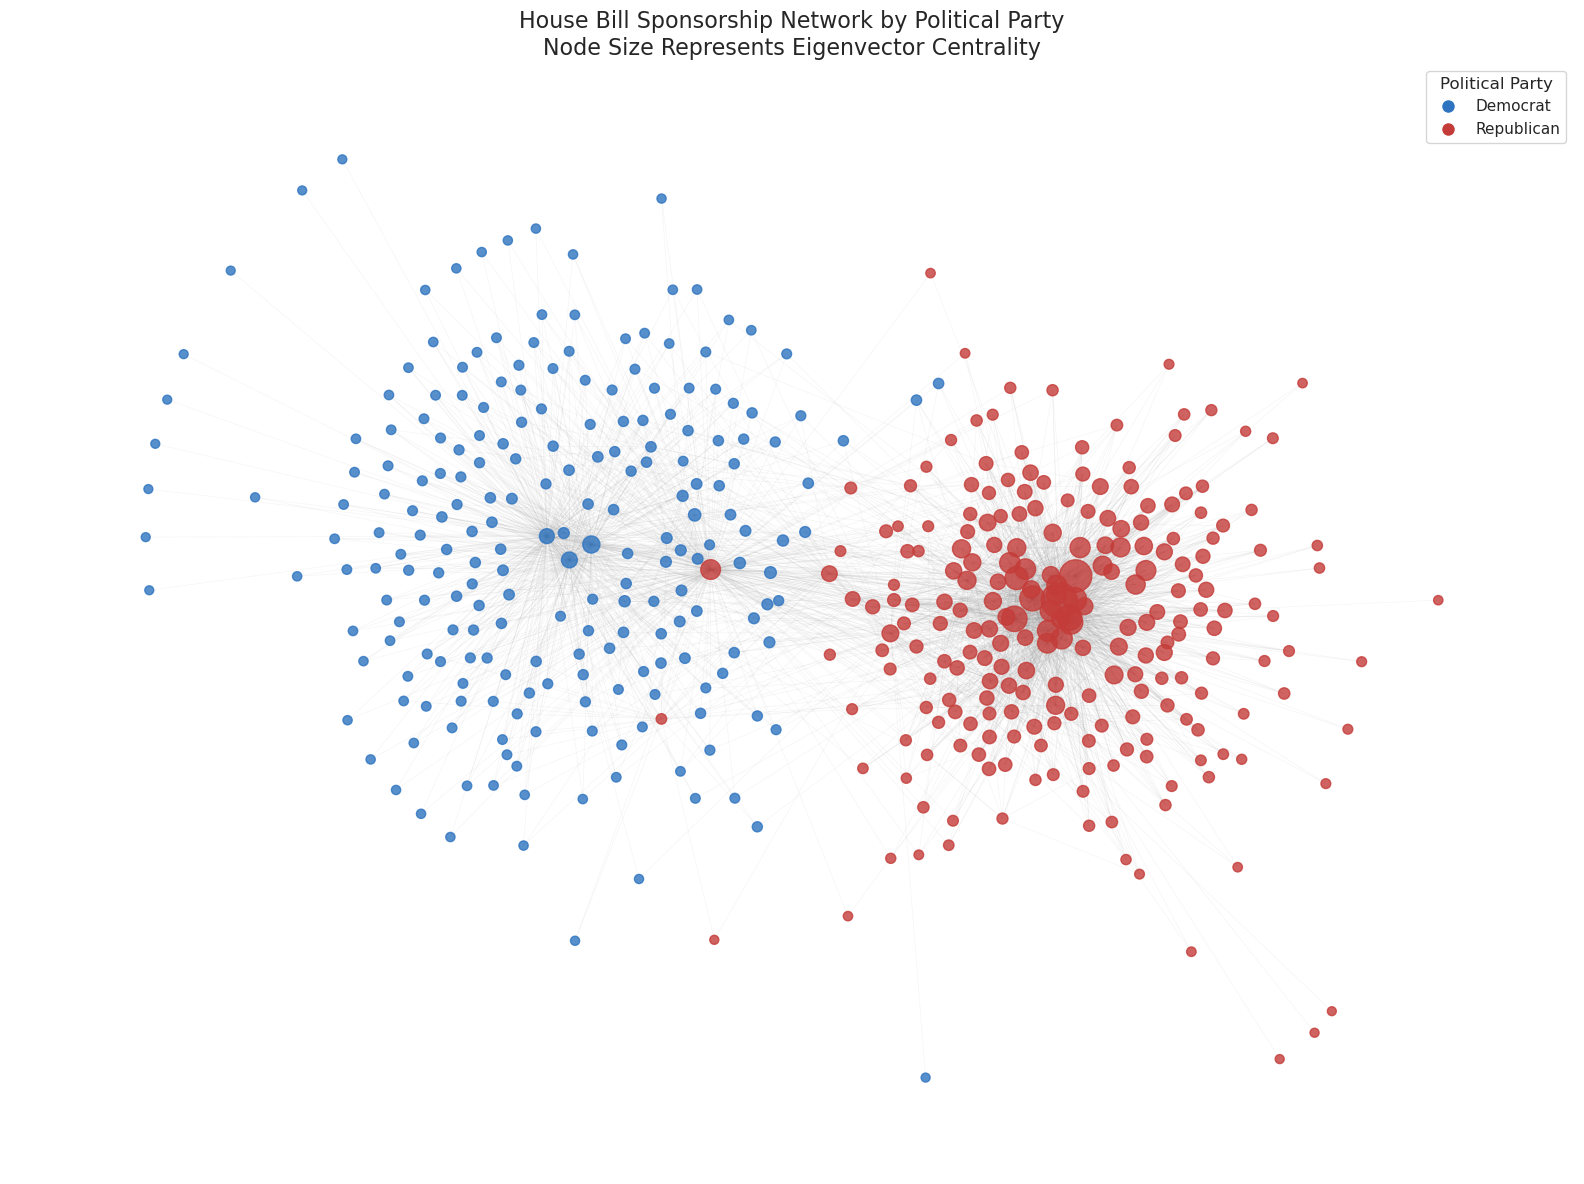

In [22]:
from matplotlib.lines import Line2D

# Create reproducible node positions
positions = nx.spring_layout(
    G,
    seed=42,
    k=0.25,
    iterations=100,
    weight="weight"
)

# Assign node colors based on political party
node_colors = [
    "#2E74C0" if G.nodes[node].get("party") == "D" else "#C43C39"
    for node in G.nodes()
]

# Make influential representatives appear larger
node_sizes = [
    40 + (eigenvector_centrality[node] * 1500)
    for node in G.nodes()
]

plt.figure(figsize=(16, 12))

# Draw sponsorship connections
nx.draw_networkx_edges(
    G,
    positions,
    alpha=0.08,
    width=0.5,
    edge_color="gray"
)

# Draw representatives
nx.draw_networkx_nodes(
    G,
    positions,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.8
)

# Label the five highest-scoring representatives
top_five_nodes = centrality_df.nlargest(
    5, "eigenvector_centrality"
)["member_id"].tolist()

top_labels = {
    node: G.nodes[node].get("name")
    for node in top_five_nodes
}

# Create the party legend
legend_items = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Democrat",
        markerfacecolor="#2E74C0",
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Republican",
        markerfacecolor="#C43C39",
        markersize=10
    )
]

plt.legend(handles=legend_items, title="Political Party")

plt.title(
    "House Bill Sponsorship Network by Political Party\n"
    "Node Size Represents Eigenvector Centrality",
    fontsize=16
)

plt.axis("off")
plt.tight_layout()
plt.show()

## Network Interpretation

The visualization shows two noticeable clusters based on political party. Most Democratic representatives appear together on the left, while most Republican representatives appear together on the right. This suggests that bill sponsorship relationships occurred more frequently among members of the same party. However, the connections between the clusters also show that some bipartisan collaboration occurred.

The larger nodes are concentrated mainly within the Republican cluster, which supports the statistical finding that Republicans had higher eigenvector centrality in this sample. These representatives were not only well connected but were also connected to other highly influential members.

## Limitations

This analysis used a sample of 250 House bills from the 118th Congress rather than every bill introduced during the congressional term. The findings may therefore be influenced by the specific bills included in the sample. Republicans also held the House majority during the 118th Congress, which may have affected sponsorship activity and network position.

The network represents sponsor-to-cosponsor relationships. It does not assume that every cosponsor of the same bill directly collaborated with every other cosponsor. In addition, the 448 representatives include members who served at different times because House membership changed during the congressional term.

Finally, centrality values come from members of the same connected network, so the observations are not completely independent. The t-tests are useful for comparing the groups, but their results should be interpreted together with the descriptive statistics and visualizations.

## Conclusion

This project analyzed bill sponsorship relationships among 448 members of the U.S. House of Representatives using 250 bills from the 118th Congress. The resulting network contained 3,038 unique connections and formed one connected component.

Republicans had significantly higher mean degree centrality and eigenvector centrality than Democrats, with p-values below 0.0001 for both comparisons. Garret Graves had the highest degree centrality, while Jeff Duncan had the highest eigenvector centrality. All ten representatives with the highest eigenvector centrality were Republicans.

Overall, the results suggest that Republican representatives occupied more central and influential positions within this sample of House bill sponsorship relationships. However, these findings describe the selected sample and should not be interpreted as evidence about every bill or every form of congressional collaboration.

In [23]:
# Save the representative-level centrality results
centrality_df.to_csv(
    "congress_centrality_results.csv",
    index=False
)

print("Centrality results saved successfully.")

Centrality results saved successfully.
